# 1-Understanding the Data
 
 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

In [5]:
df.head(
)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [10]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2087 non-null   str    
 1   Age                             2087 non-null   int64  
 2   Height                          2087 non-null   float64
 3   Weight                          2087 non-null   float64
 4   family_history_with_overweight  2087 non-null   str    
 5   FAVC                            2087 non-null   str    
 6   FCVC                            2087 non-null   float64
 7   NCP                             2087 non-null   float64
 8   CAEC                            2087 non-null   str    
 9   SMOKE                           2087 non-null   str    
 10  CH2O                            2087 non-null   float64
 11  SCC                             2087 non-null   str    
 12  FAF                             2087 non-null   fl

In [6]:
#Inspect shape, columns, data types
print( " Data shape:" , df.shape)
print("\n Column names: \n", df.columns)
print("\nData types:\n", df.dtypes)

 Data shape: (2111, 17)

 Column names: 
 Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='str')

Data types:
 Gender                                str
Age                                 int64
Height                            float64
Weight                            float64
family_history_with_overweight        str
FAVC                                  str
FCVC                              float64
NCP                               float64
CAEC                                  str
SMOKE                                 str
CH2O                              float64
SCC                                   str
FAF                               float64
TUE                               float64
CALC                                  str
MTRANS                                str
NObeyesdad                            str
dtype: object


# 2-Data cleaning

In [7]:
#Identify missing values
print("\nMissing values in each column:\n", df.isnull().sum())


Missing values in each column:
 Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


In [8]:
df.duplicated().sum()

np.int64(24)

In [9]:
df.drop_duplicates(inplace=True)

# ── 2. EDA ────────────────────────────────────────────────────────────────────


# Target distribution


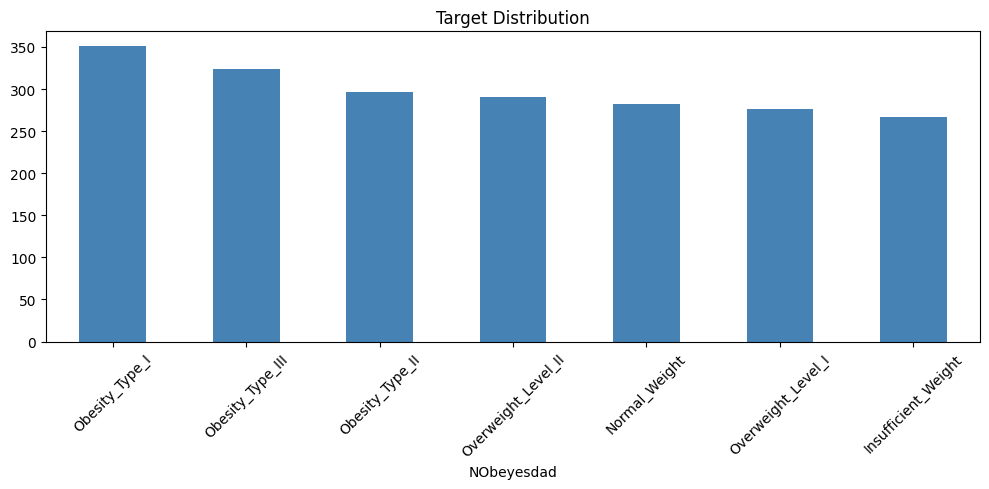

In [28]:
plt.figure(figsize=(10, 5))
df['NObeyesdad'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Target Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('01_target_distribution.png')
plt.show()
 

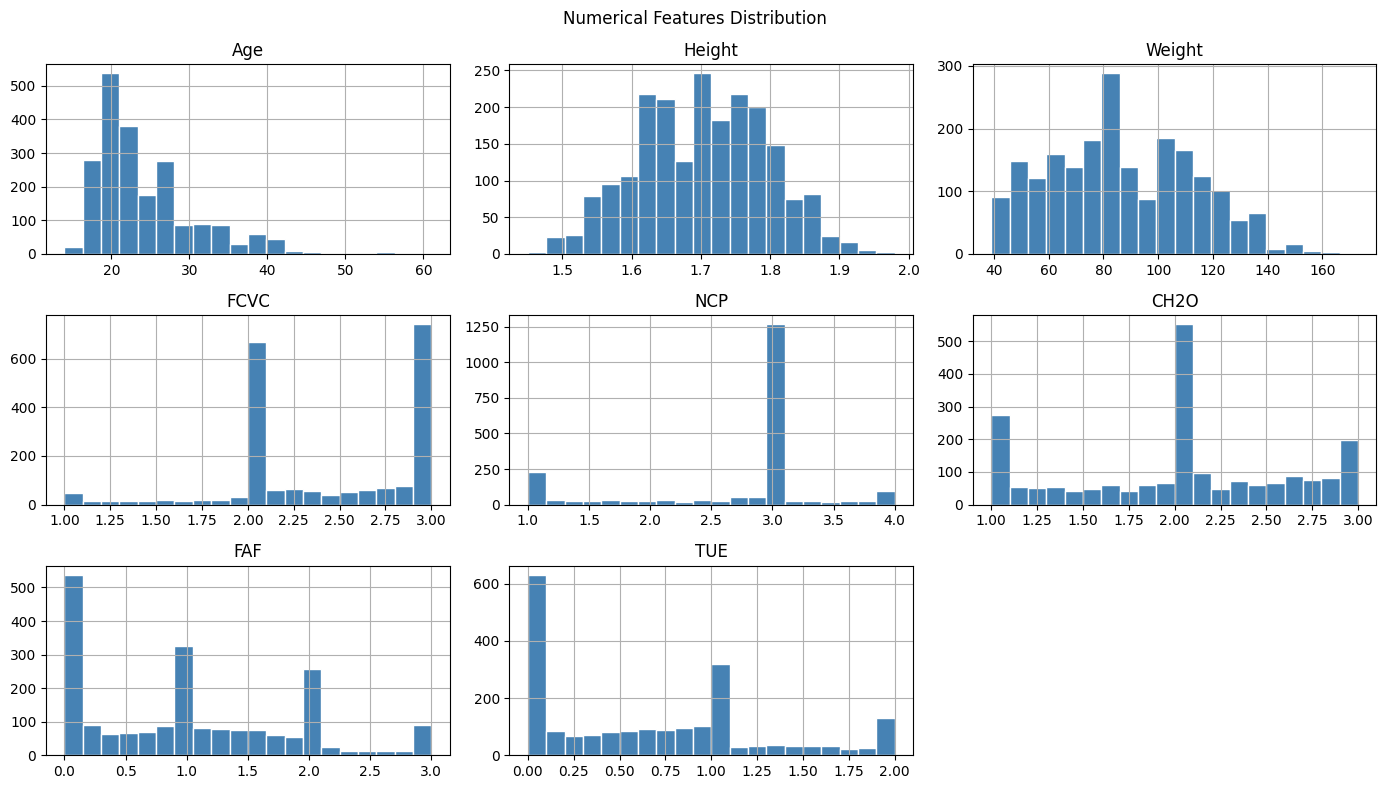

In [29]:
# Numerical distributions
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df[num_cols].hist(bins=20, figsize=(14, 8), color='steelblue', edgecolor='white')
plt.suptitle('Numerical Features Distribution')
plt.tight_layout()
plt.savefig('02_numerical_distributions.png')
plt.show()

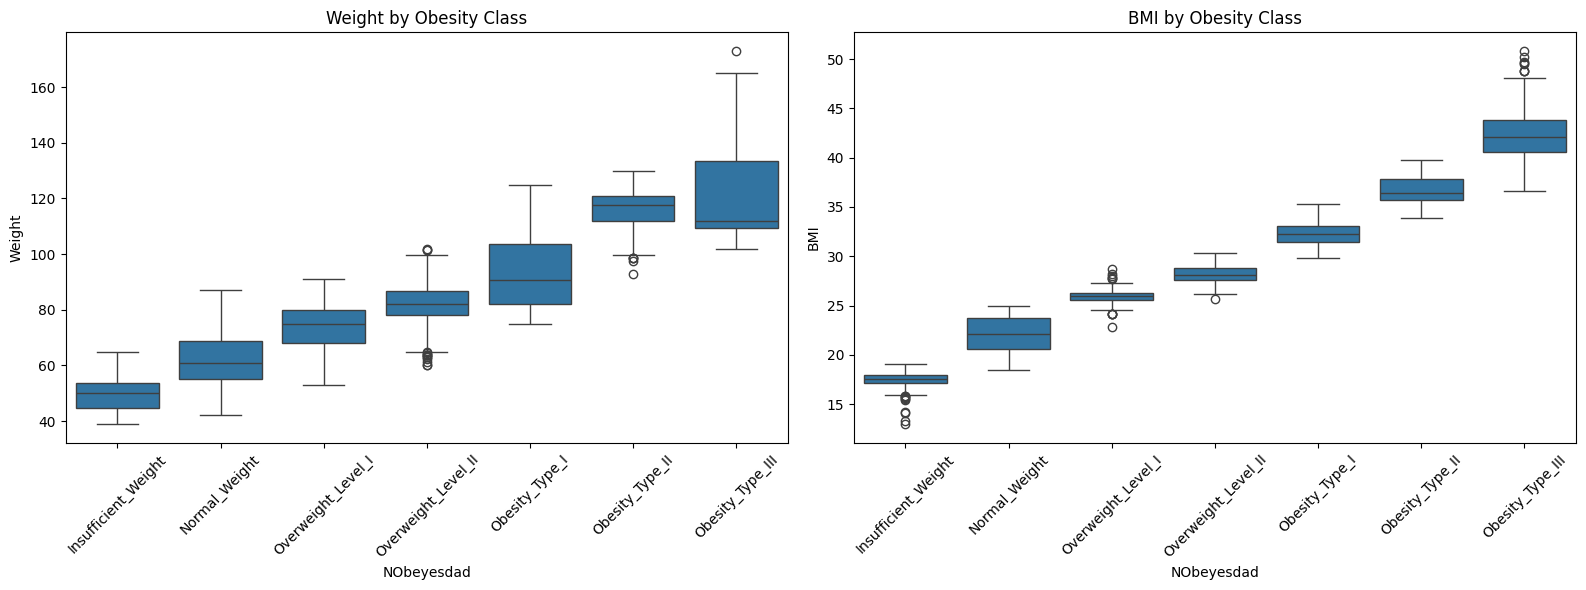

In [31]:
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='NObeyesdad', y='Weight', data=df, order=order, ax=axes[0])
axes[0].set_title('Weight by Obesity Class')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='NObeyesdad', y='BMI', data=df, order=order, ax=axes[1])
axes[1].set_title('BMI by Obesity Class')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('03_boxplots.png', dpi=300)
plt.show()

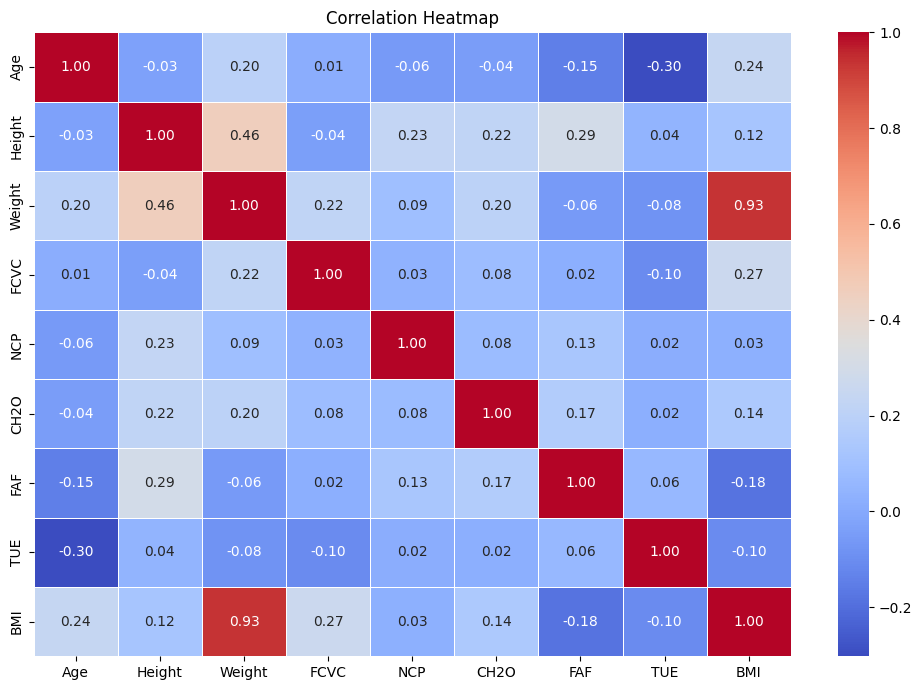

In [33]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols + ['BMI']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('04_correlation.png')
plt.show()
 

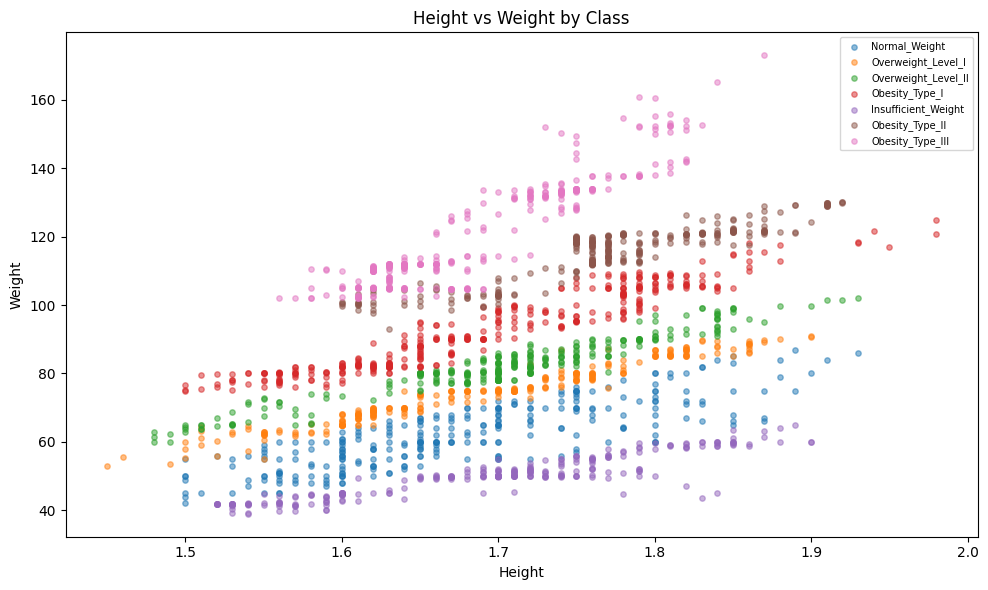

In [34]:
# Scatter: Height vs Weight colored by class
plt.figure(figsize=(10, 6))
for cls in df['NObeyesdad'].unique():
    sub = df[df['NObeyesdad'] == cls]
    plt.scatter(sub['Height'], sub['Weight'], label=cls, alpha=0.5, s=15)
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight by Class')
plt.legend(fontsize=7, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('06_scatter.png')
plt.show()
 

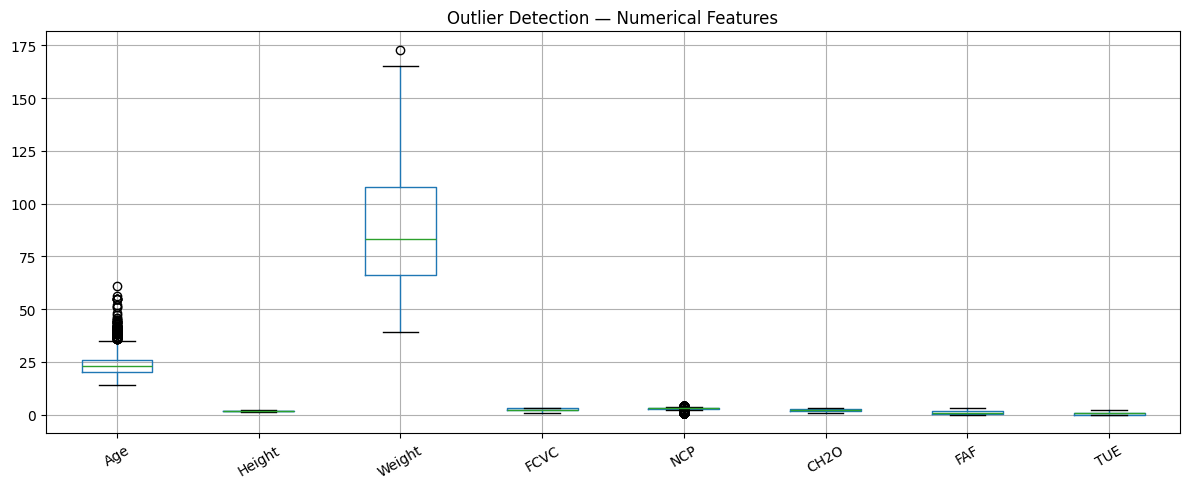

In [35]:
# Outliers: boxplot for all numericals
plt.figure(figsize=(12, 5))
df[num_cols].boxplot()
plt.title('Outlier Detection — Numerical Features')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('07_outliers.png')
plt.show()
 

3-Data Preprocessing

In [19]:
df['BMI'] = df['Weight'] / (df['Height'] ** 2)
print(df['BMI'].head())

0    24.386526
1    24.238227
2    23.765432
3    26.851852
4    28.342381
Name: BMI, dtype: float64


4-model
